# Urban Networks I

Overview of today's topics:
  - Network modeling and analysis with NetworkX
  - Spatial network modeling and analysis with OSMnx and OpenStreetMap

For more, see:
  - OSMnx [Documentation](https://osmnx.readthedocs.io/)
  - OSMnx [Examples Gallery](https://github.com/gboeing/osmnx-examples)

In [18]:
!curl -s -o pyproject.toml https://raw.githubusercontent.com/gboeing/osmnx-workshop/refs/heads/main/pyproject.toml && uv pip install -r pyproject.toml

Using Python 3.12.12 environment at: /usr
Resolved 114 packages in 1.04s
Audited 114 packages in 4ms


In [19]:
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd

# configure OSMnx
ox.settings.log_console = True
print(ox.__version__)

2.1.0


## 1. Network analysis with NetworkX

Networks let you represent structure and interaction among the components of a system. In analytics, they let you go beyond models that average across individuals/components or treat the population/system as a monolith. Networks are useful when the system's structure is nontrivial.

A network is a set of objects (called nodes or vertices) connected to each other by a set of connections (called edges or links). A graph is a mathematical model of a network: usually used synonymously. You can represent a graph as an adjacency matrix to use the tools of linear algebra to analyze it. You can also simulate dynamics and flows on it.

A trivial (simple) network is undirected, unweighted, and lacks self-loops or parallel edges. A nontrivial (complex) network may be directed and weighted and have self-loops and parallel edges. A spatial network is a network that is spatially embedded. That means its nodes and/or edges have locations in space. A spatial network is defined by both its geometry (positions, distances, angles, etc) and its topology (connections and configurations).

Examples:

  - street networks
  - airline routes
  - rail lines
  - capital flows
  - spread of contagious diseases

We can analyze a network in various ways. To take street networks as an example, you can measure its compactness via intersection density, its connectedness via average node degree, or the relative importance of different nodes via centrality. Betweenness centrality measures what share of all shortest paths in a network pass through each node. Closeness centrality measures the average distance between a node and all other nodes in the network.

In [20]:
# create a random small-world graph of a social network
G = nx.watts_strogatz_graph(n=100, k=5, p=0.1, seed=0)

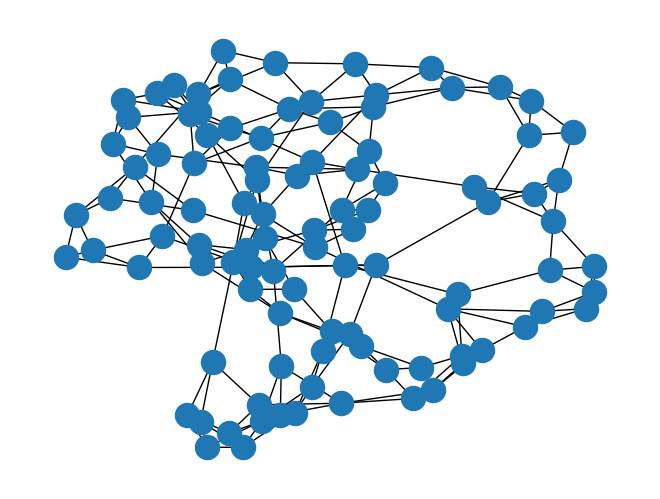

In [21]:
nx.draw(G)

In [22]:
# how many nodes and edges?
print(len(G.nodes))
print(len(G.edges))

100
200


In [23]:
# assign random ages to each person in the network
randoms = np.random.randint(low=18, high=90, size=len(G.nodes))
ages = {node: age for node, age in zip(G.nodes, randoms)}
nx.set_node_attributes(G, values=ages, name="age")

In [24]:
# assign random "social distance" to each edge in the network
# social distance is the inverse of how often they hang out each year
hangout_counts = np.random.randint(low=1, high=100, size=len(G.edges))
distances = {edge: 1 / hangout_count for edge, hangout_count in zip(G.edges, hangout_counts)}
nx.set_edge_attributes(G, values=distances, name="distance")

In [25]:
# view the nodes and optionally show their attribute data
G.nodes  # (data=True)

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99))

In [26]:
# view the edges and optionally show their attribute data
# these are undirected edges, and there cannot be parallel edges
G.edges  # (data=True)

EdgeView([(0, 1), (0, 99), (0, 2), (0, 98), (1, 2), (1, 3), (1, 99), (2, 3), (2, 4), (2, 17), (3, 4), (3, 5), (4, 5), (4, 6), (4, 92), (5, 6), (5, 7), (6, 7), (6, 73), (7, 8), (7, 9), (8, 9), (8, 10), (9, 10), (9, 11), (9, 27), (10, 11), (10, 15), (11, 12), (11, 13), (12, 13), (12, 14), (12, 32), (13, 14), (13, 15), (14, 15), (14, 16), (15, 16), (15, 17), (16, 17), (16, 18), (17, 18), (18, 19), (18, 20), (19, 20), (19, 21), (20, 21), (20, 22), (20, 87), (21, 22), (21, 23), (22, 23), (22, 24), (23, 24), (23, 86), (24, 25), (24, 54), (24, 74), (25, 26), (25, 27), (26, 27), (26, 28), (27, 28), (28, 29), (28, 30), (29, 30), (29, 31), (30, 31), (30, 32), (31, 32), (31, 33), (32, 33), (33, 34), (33, 35), (34, 35), (34, 36), (34, 97), (35, 37), (35, 92), (35, 61), (36, 37), (36, 38), (37, 38), (37, 39), (38, 39), (38, 40), (39, 40), (39, 41), (40, 41), (40, 42), (40, 50), (41, 42), (41, 43), (42, 43), (42, 44), (43, 44), (43, 45), (44, 45), (44, 46), (45, 47), (45, 72), (46, 47), (46, 48), (4

In [27]:
# calculate the shortest path between two nodes
path1 = nx.shortest_path(G, source=0, target=50)
path1

[0, 2, 17, 18, 20, 87, 50]

In [30]:
# calculate the shortest weighted path between two nodes
path2 = nx.shortest_path(G, source=0, target=50, weight="distance")
path2

[0, 2, 17, 18, 20, 87, 50]

In [31]:
# calculate node betweenness centrality across the network
bc = nx.betweenness_centrality(G, weight="distance")
pd.Series(bc).describe()

,0
count,100.000000
mean,0.047368
std,0.046962
min,0.000000
25%,0.011905
50%,0.032983
75%,0.067409
max,0.251082


In [32]:
# now it's your turn
# try changing the social distance between our people, then recompute a shortest path

There is nothing explicitly spatial about the graph above. Although it models people and their relationships, it captures nothing about their positions in space. Now let's look at real-world spatial networks.

## 2. Spatial networks and OSMnx

OSMnx lets you download, model, analyze, and visualize street networks (and any other spatial data) anywhere in the world from OpenStreetMap.

OSMnx is built on top of GeoPandas, NetworkX, and matplotlib and interacts with OpenStreetMap’s APIs to:

  - Download and model street networks or other networked infrastructure anywhere in the world with a single line of code
  - Download any other spatial geometries, place boundaries, building footprints, or points of interest as a GeoDataFrame
  - Download by city name, polygon, bounding box, or point/address + network distance
  - Download drivable, walkable, bikeable, or all street networks
  - Download node elevations and calculate edge grades (inclines)
  - Impute missing speeds and calculate graph edge travel times
  - Simplify and correct the network’s topology to clean-up nodes and consolidate intersections
  - Fast map-matching of points, routes, or trajectories to nearest graph edges or nodes
  - Save networks to disk as shapefiles, GeoPackages, and GraphML
  - Save/load street network to/from a local .osm XML file
  - Conduct topological and spatial analyses to automatically calculate dozens of indicators
  - Calculate and visualize street bearings and orientations
  - Calculate and visualize shortest-path routes that minimize distance, travel time, elevation, etc
  - Visualize street networks as a static map or interactive Leaflet web map
  - Visualize travel distance and travel time with isoline and isochrone maps
  - Plot figure-ground diagrams of street networks and building footprints

More info:

  - [OSMnx documentation](https://osmnx.readthedocs.io)
  - [Examples, demos, tutorials](https://github.com/gboeing/osmnx-examples)

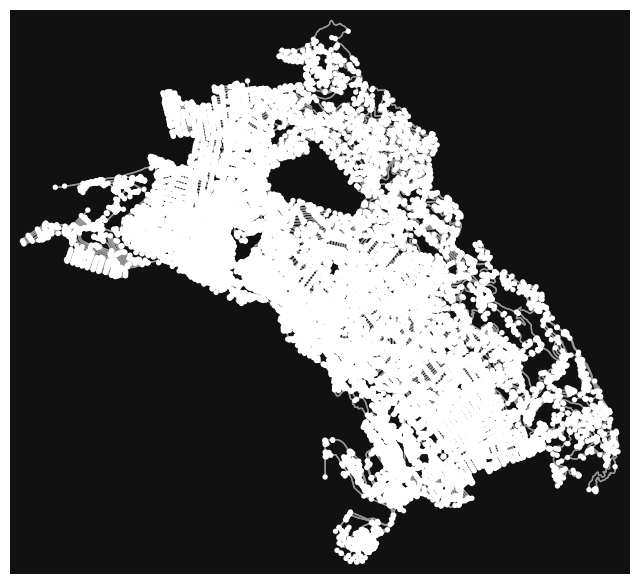

In [35]:
# download/model a street network for some city then visualize it
place = "Oakland, California, USA"
G = ox.graph.graph_from_place(place, network_type="bike")
fig, ax = ox.plot.plot_graph(G)

OSMnx geocodes the query "Piedmont, California, USA" to retrieve the place boundaries of that city from the Nominatim API, retrieves the drivable street network data within those boundaries from the Overpass API, constructs a graph model, then simplifies/corrects its topology such that nodes represent intersections and dead-ends and edges represent the street segments linking them.

In [36]:
# look at the first 10 nodes: these are OSM IDs
list(G.nodes)[0:10]

[30364114,
 35718715,
 35718727,
 35718864,
 35719057,
 35719067,
 52979813,
 52979815,
 52981368,
 52981390]

In [37]:
# look at the first 10 edges: u, v, key
list(G.edges)[0:10]

[(30364114, 99591354, 0),
 (30364114, 99582488, 0),
 (35718715, 4121711518, 0),
 (35718715, 35719057, 0),
 (35718715, 35718727, 0),
 (35718727, 842991781, 0),
 (35718727, 8141442226, 0),
 (35718727, 35718715, 0),
 (35718864, 6857863609, 0),
 (35718864, 91846726, 0)]

In [38]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

OSMnx models all networks as NetworkX `MultiDiGraph` objects. You can convert to:

  - undirected NetworkX MultiGraphs
  - NetworkX DiGraphs without (possible) parallel edges
  - GeoPandas node/edge GeoDataFrames

In [39]:
# convert your graph to node and edge GeoPandas GeoDataFrames
gdf_nodes, gdf_edges = ox.convert.graph_to_gdfs(G)
gdf_nodes.head()

,y,x,street_count,highway,junction,railway,geometry
osmid,,,,,,,
30364114,37.822884,-122.301088,2,NaN,NaN,NaN,POINT (-122.30109 37.82288)
35718715,37.860976,-122.243368,3,NaN,NaN,NaN,POINT (-122.24337 37.86098)
35718727,37.861797,-122.241571,3,NaN,NaN,NaN,POINT (-122.24157 37.8618)
35718864,37.868358,-122.217862,4,stop,yes,NaN,POINT (-122.21786 37.86836)
35719057,37.860731,-122.244055,3,NaN,NaN,NaN,POINT (-122.24405 37.86073)


In [40]:
gdf_edges.head()

osmid  \
u        v          key                                                  
30364114 99591354   0                                         11192270   
         99582488   0                                        202317724   
35718715 4121711518 0                                          5149903   
         35719057   0                                        188702003   
         35718727   0    [5149907, 1174749164, 1174749165, 1174749166]   

                              highway lanes maxspeed  oneway reversed  \
u        v          key                                                 
30364114 99591354   0    primary_link     3   50 mph    True    False   
         99582488   0    primary_link     1   50 mph    True    False   
35718715 4121711518 0       secondary     2   25 mph   False    False   
         35719057   0       secondary     2   25 mph   False     True   
         35718727   0     residential     1      NaN   False    False   

                             length  \
u        v          key               
30364114 99591354   0     59.125131   
         99582488   0     82.345272   
35718715 4121711518 0    107.319973   
         35719057   0     66.827679   
         35718727   0    469.407248   

                                                                  geometry  \
u        v          key                                                      
30364114 99591354   0    LINESTRING (-122.30109 37.82288, -122.30072 37...   
         99582488   0    LINESTRING (-122.30109 37.82288, -122.3008 37....   
35718715 4121711518 0    LINESTRING (-122.24337 37.86098, -122.24328 37...   
         35719057   0    LINESTRING (-122.24337 37.86098, -122.24352 37...   
         35718727   0    LINESTRING (-122.24337 37.86098, -122.24337 37...   

                                     name service bridge access  ref junction  \
u        v          key                                                         
30364114 99591354   0                 NaN     NaN    NaN    NaN  NaN      NaN   
         99582488   0                 NaN     NaN    NaN    NaN  NaN      NaN   
35718715 4121711518 0    Claremont Avenue     NaN    NaN    NaN  NaN      NaN   
         35719057   0    Claremont Avenue     NaN    NaN    NaN  NaN      NaN   
         35718727   0      Stonewall Road     NaN    NaN    NaN  NaN      NaN   

                        est_width tunnel width area  
u        v          key                              
30364114 99591354   0         NaN    NaN   NaN  NaN  
         99582488   0         NaN    NaN   NaN  NaN  
35718715 4121711518 0         NaN    NaN   NaN  NaN  
         35719057   0         NaN    NaN   NaN  NaN  
         35718727   0         NaN    NaN   NaN  NaN

You can create a graph from node/edge GeoDataFrames, as long as gdf_nodes is indexed by osmid and gdf_edges is multi-indexed by u, v, key (following normal MultiDiGraph structure). This allows you to load graph node/edge shapefiles or GeoPackage layers as GeoDataFrames then convert to a MultiDiGraph for graph analytics.

In [41]:
# convert node/edge GeoPandas GeoDataFrames to a NetworkX MultiDiGraph
G2 = ox.convert.graph_from_gdfs(gdf_nodes, gdf_edges, graph_attrs=G.graph)
print(len(G2.nodes))
print(len(G2.edges))

21066
51923


In [ ]:
# now it's your turn
# download a graph of a different (small-ish) town, then plot it
place = "Alameda, California, USA"
G = ox.graph.graph_from_place(place, network_type="bike")
fig, ax = ox.plot.plot_graph(G)

## Basic street network stats

In [ ]:
# get our study site's geometry
gdf = ox.geocoder.geocode_to_gdf(place)
gdf_proj = ox.projection.project_gdf(gdf)
geom_proj = gdf_proj["geometry"].iloc[0]
geom_proj

In [ ]:
# what size area does our study site cover in square meters?
area_m = geom_proj.area
area_m

In [ ]:
# project the graph (automatically) then check its new CRS
G_proj = ox.projection.project_graph(G)
G_proj.graph["crs"]

In [ ]:
# show some basic stats about the (projected) network
ox.stats.basic_stats(G_proj, area=area_m, clean_int_tol=10)

More stats [documentation](https://osmnx.readthedocs.io/en/stable/osmnx.html#module-osmnx.stats)

In [ ]:
# save graph to disk as geopackage (for GIS) or GraphML file (for Gephi etc)
ox.io.save_graph_geopackage(G, filepath="./data/mynetwork.gpkg")
ox.io.save_graphml(G, filepath="./data/mynetwork.graphml")

## Visualize street centrality

Here we plot the street network and color its edges (streets) by their relative closeness centrality.

In [ ]:
# convert graph to line graph so edges become nodes and vice versa
edge_centrality = nx.closeness_centrality(nx.line_graph(G))
nx.set_edge_attributes(G, edge_centrality, "edge_centrality")

In [ ]:
# color edges in original graph with centralities from line graph
ec = ox.plot.get_edge_colors_by_attr(G, "edge_centrality", cmap="inferno")
fig, ax = ox.plot.plot_graph(G, edge_color=ec, edge_linewidth=2, node_size=0)

## Routing

In [ ]:
# impute missing edge speeds then calculate edge (free-flow) travel times
G = ox.routing.add_edge_speeds(G)
G = ox.routing.add_edge_travel_times(G)

In [ ]:
# get the nearest network nodes to two lat/lng points
orig = ox.distance.nearest_nodes(G, -122.245846, 37.828903)
dest = ox.distance.nearest_nodes(G, -122.215006, 37.812303)

In [ ]:
# find the shortest path between these nodes, minimizing travel time, then plot it
route = ox.routing.shortest_path(G, orig, dest, weight="travel_time")
fig, ax = ox.plot.plot_graph_route(G, route, node_size=0)

In [ ]:
# how long is our route in meters?
edge_lengths = ox.routing.route_to_gdf(G, route)["length"]
sum(edge_lengths)

In [ ]:
# how far is it between these two nodes as the crow flies (haversine)?
ox.distance.great_circle(
    G.nodes[orig]["y"], G.nodes[orig]["x"], G.nodes[dest]["y"], G.nodes[dest]["x"]
)

In [ ]:
# now it's your turn
# how circuitous is this route?
# try plotting it differently: change the colors and node/edge sizes

## Get networks other ways

make queries less ambiguous to help the geocoder out, if it's not finding what you're looking for

In [ ]:
# you can make query an unambiguous dict to help the geocoder find it
place = {"city": "San Francisco", "state": "California", "country": "USA"}
G = ox.graph.graph_from_place(place, network_type="drive", truncate_by_edge=True)
fig, ax = ox.plot.plot_graph(G, figsize=(10, 10), node_size=0, edge_color="y", edge_linewidth=0.2)

In [ ]:
# you can get networks anywhere in the world
G = ox.graph.graph_from_place("Sinalunga, Italy", network_type="all")
fig, ax = ox.plot.plot_graph(G, node_size=0, edge_linewidth=0.5)

In [ ]:
# or get network by address, coordinates, bounding box, or any custom polygon
# ...useful when OSM just doesn't already have a polygon for the place you want
lewis_hall = (34.019267, -118.283566)
one_mile = 1609  # meters
G = ox.graph.graph_from_point(lewis_hall, dist=one_mile, network_type="drive")
fig, ax = ox.plot.plot_graph(G, node_size=0)

Consider study area boundaries and the artificial perimeter problem.

In [ ]:
# now it's your turn
# create a graph of your hometown
# then calculate the shortest path between two points of your choice

## Get other networked infrastructure types

...like rail or electric grids or even the canals of Venice and Amsterdam, using the `custom_filter` parameter. See the Overpass Query Language documentation for query usage details.

In [ ]:
# get NY subway rail network
G = ox.graph.graph_from_place(
    "New York City, New York, USA",
    retain_all=False,
    truncate_by_edge=True,
    simplify=True,
    custom_filter='["railway"~"subway"]',
)

fig, ax = ox.plot.plot_graph(G, node_size=0, edge_color="c", edge_linewidth=0.2)

## Get any geospatial entities' geometries and attributes

Use the `features` module to download entities, such as local amenities, points of interest, or building footprints, and turn them into a GeoDataFrame.

In [ ]:
# get all building footprints in some neighborhood
place = "Loop, Chicago, IL, USA"
tags = {"building": True}
gdf = ox.features.features_from_place(place, tags)
gdf.shape

In [ ]:
fig, ax = ox.plot.plot_footprints(gdf, figsize=(3, 3))

In [ ]:
# get all parks and bus stops in some neighborhood
tags = {"leisure": "park", "highway": "bus_stop"}
gdf = ox.features.features_from_place(place, tags)
gdf.shape

In [ ]:
# restaurants near the empire state buildings
address = "350 5th Ave, New York, NY 10001"
tags = {"amenity": "restaurant"}
gdf = ox.features.features_from_address(address, tags=tags, dist=500)
gdf[["name", "cuisine", "geometry"]].dropna().head()

In [ ]:
# now it's your turn
# find all the rail stations around central CDMX
# hint, the tag is railway and the value is station:
# https://wiki.openstreetmap.org/wiki/Tag:railway%3Dstation